# Wrapper Feature Selection — Example Notebook

Demonstrates **`WrapperSelector`** on the SCANB gene-expression dataset.

| Task | Target | Type | Algorithm | SU Mode |
|------|--------|------|-----------|----------|
| **A** | `is_lumA` | classification | IWSS-MB | Mode A — precomputed SU matrix (with MI interim save) |
| **B** | `Lympho` | regression | IWSS-MB | Mode A — precomputed SU matrix |
| **C** | `is_lumA` | classification | all four variants | Mode B — lazy incremental fill |

**Features demonstrated:**
- `ScoreMatrix` with `method="su"` — replaces `ScoreMatrix`
- Mode A precomputation (CSV/Parquet load/save) and Mode B lazy `ScoreCalculator` fill
- `cv_folds` / `cv_min_folds` dual-condition acceptance
- `mb_threshold` — configurable MB pruning margin (conservative pruning control)
- `PATIENCE` stopping (global, default `None`)
- `test_eval_every_k` validation evaluation
- SU statistics exploration (feature–target, feature–feature, and pruning‐margin distributions)
- `WrapperSelectionResult` timing breakdown
- `SelectionResult.compare_results` for multi-algorithm comparison
- `SelectionResult.compare_with` for pairwise rank-aligned feature diff
- `SelectionResult.summary_report` for multi-result feature summary
- `plot_vs_random_baseline` for classification and regression

## 0 — Imports & paths

In [32]:
import sys, os

# Make sure the package root is on the path when running from feature_selection/src/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from feature_selection.src.preprocessing import train_test_val_split
from feature_selection.src.score_matrix import ScoreMatrix
from feature_selection.src.wrapper.MarkovBlanketWrapper import WrapperSelector
from feature_selection.src.results import SelectionResult, WrapperSelectionResult
from feature_selection.src.LR_random_baseline import plot_performance_with_stats as clf_baseline_plot
from feature_selection.src.LR_regression_baseline import plot_performance_with_stats as reg_baseline_plot

# ── Paths (relative to notebook location: feature_selection/src/) ──────────
DATA_PATH  = '../data/SCANB.csv'
LABEL_PATH = '../data/sampleinfo_SCANB_t.csv'

# Precomputed SU matrix — single file shared across all tasks on the same feature set
# Feature-pair SU values are target-independent; only the target column differs.
SU_PATH = '../data/su_matrix.csv'   # shared SU matrix (features + all targets)

# ── Globals ────────────────────────────────────────────────────────────────
RANDOM_SEED     = 2
N_FEATURES      = 20    # features to select
TEST_EVAL_EVERY = 2     # run test/val evaluation every k selections
N_RUNS          = 10    # random baseline runs
CV_FOLDS        = 5
CV_MIN_FOLDS    = 3
PATIENCE        = None  # stop after N consecutive non-improvements; None = no limit
MB_THRESHOLD    = 1e-2   # MB pruning margin; 0.0 = original Definition 5; positive = more conservative

## 1 — Load data & build train / validation splits

In [9]:
gene_expression_df = pd.read_csv(DATA_PATH)
sampleinfo_df      = pd.read_csv(LABEL_PATH)

# Binary LumA label
sampleinfo_df['is_lumA'] = (sampleinfo_df['PAM50'] == 'LumA').astype(int)

# 70% train / 10% val / 20% test
train_si, val_si, _ = train_test_val_split(
    sampleinfo_df, random_seed=RANDOM_SEED, train_pcnt=0.7, val_pct=0.1
)

train_labels_df = train_si[['samplename', 'is_lumA']].reset_index(drop=True)
val_labels_df   = val_si[['samplename', 'is_lumA']].reset_index(drop=True)

print(f'Train samples : {len(train_labels_df)}')
print(f'Val   samples : {len(val_labels_df)}')
print(f"LumA prevalence (train): {train_labels_df['is_lumA'].mean():.2%}")

# Transpose gene-expression (genes × samples) → (samples × genes)
ge_proc = gene_expression_df.copy().fillna(0).set_index('Unnamed: 0').T
ge_proc.index.name = 'samplename'

X_train = ge_proc.loc[train_labels_df['samplename']]
X_val   = ge_proc.loc[val_labels_df['samplename']]

print(f'\nX_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')

Train samples : 2148
Val   samples : 306
LumA prevalence (train): 49.30%

X_train shape : (2148, 9264)
X_val   shape : (306, 9264)


## 2 — Build target series

In [3]:
# Classification target: is_lumA
y_lumA = (
    train_labels_df.set_index('samplename')['is_lumA']
    .reindex(X_train.index)
)  # Series.name == 'is_lumA'

y_lumA_val = (
    val_labels_df.set_index('samplename')['is_lumA']
    .reindex(X_val.index)
)

# Regression target: Lympho
y_lympho = (
    sampleinfo_df.set_index('samplename')['Lympho']
    .reindex(X_train.index)
)  # Series.name == 'Lympho'

y_lympho_val = (
    sampleinfo_df.set_index('samplename')['Lympho']
    .reindex(X_val.index)
)

print(f'y_lumA   name={y_lumA.name!r}    dtype={y_lumA.dtype}   nunique={y_lumA.nunique()}')
print(f'y_lympho name={y_lympho.name!r}  dtype={y_lympho.dtype}   nunique={y_lympho.nunique()}')

y_lumA   name='is_lumA'    dtype=int64   nunique=2
y_lympho name='Lympho'  dtype=float64   nunique=2148


---

## Precomputation — SU matrix (Mode A)

**Run once** to compute and save the full Symmetric Uncertainty matrix.
On subsequent runs the file is loaded directly — no recomputation.

The new `ScoreMatrix` class with `method='su'` replaces the old
precomputation classes.  It uses `ScoreCalculator`
internally with the fully vectorised `np.bincount`-based SU engine.

> **Single shared matrix**  
> Feature-pair SU values are identical regardless of which target is used, so
> there is no reason to recompute them for every task.  We build **one** matrix
> that includes both target columns (`is_lumA` and `Lympho`).


### Precompute shared SU matrix (both targets: `is_lumA` and `Lympho`)

Uses `ScoreMatrix(method='su')` — the new vectorised SU engine.


In [4]:
if not os.path.exists(SU_PATH):
    print('Computing shared SU matrix for both targets...')
    print(f'  SU matrix → {SU_PATH}')
    ScoreMatrix(
        X=X_train.fillna(0).values,
        feature_names=list(X_train.columns),
        target_names=[str(y_lumA.name), str(y_lympho.name)],
        target_data=pd.concat([y_lumA, y_lympho], axis=1).fillna(0).values,
        method='su',
        filepath=SU_PATH,
        file_format='csv',
    ).precompute()
else:
    print(f'SU matrix already exists at {SU_PATH} — skipping computation.')

# Inspect the saved SU matrix
if os.path.exists(SU_PATH):
    su_shared = pd.read_csv(SU_PATH, index_col=0)
    print(f'\nShared SU matrix shape: {su_shared.shape}')
    if 'is_lumA' in su_shared.columns:
        print('Top-5 SU values with is_lumA target:')
        print(su_shared['is_lumA'].drop('is_lumA', errors='ignore').sort_values(ascending=False).head(5).to_string())
    if 'Lympho' in su_shared.columns:
        print('\nTop-5 SU values with Lympho target:')
        print(su_shared['Lympho'].drop('Lympho', errors='ignore').sort_values(ascending=False).head(5).to_string())


SU matrix already exists at ../data/su_matrix.csv — skipping computation.

Shared SU matrix shape: (9266, 9266)
Top-5 SU values with is_lumA target:
MYBL2    0.267609
CDC45    0.258247
BIRC5    0.257759
CCNB2    0.253082
PTTG1    0.250041

Top-5 SU values with Lympho target:
CD247    0.586616
IL2RG    0.586565
ACAP1    0.584904
LCK      0.581479
CD3E     0.575799


---

## SU Statistics Exploration

Inspect the distribution of feature–feature and feature–target Symmetric
Uncertainty values from the precomputed matrix.  Understanding these
distributions helps choose a sensible `mb_threshold` and explains how
aggressively MB pruning will act.

### Feature–target SU distribution

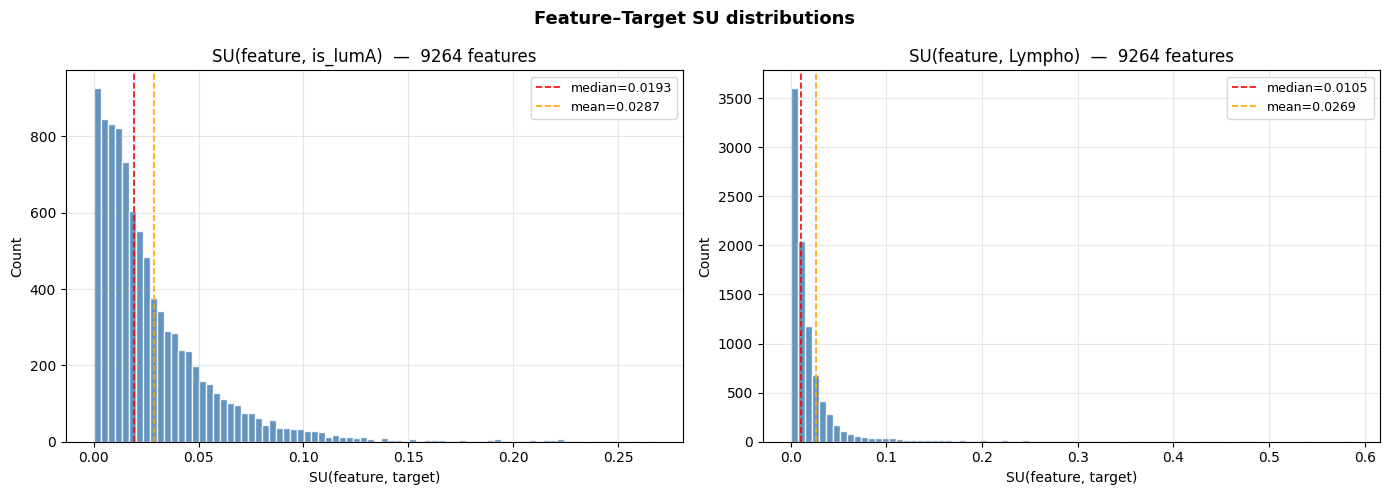


is_lumA:
count    9264.000000
mean        0.028684
std         0.030824
min         0.000000
25%         0.008887
50%         0.019326
75%         0.038502
max         0.267609

Lympho:
count    9264.000000
mean        0.026890
std         0.058069
min         0.000000
25%         0.004415
50%         0.010493
75%         0.022935
max         0.586616


In [5]:
# Load shared SU matrix (must have been computed in the Precomputation section)
su_df = pd.read_csv(SU_PATH, index_col=0)

# Feature names = everything that is NOT a target column
target_cols = ['is_lumA', 'Lympho']
feature_names = [c for c in su_df.columns if c not in target_cols]

fig, axes = plt.subplots(1, len(target_cols), figsize=(7 * len(target_cols), 5))
if len(target_cols) == 1:
    axes = [axes]

for ax, tgt in zip(axes, target_cols):
    if tgt not in su_df.columns:
        ax.set_title(f'{tgt} — not in matrix'); continue
    su_ft = su_df.loc[feature_names, tgt].dropna()
    ax.hist(su_ft.values, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(su_ft.median(), color='red', ls='--', lw=1.2, label=f'median={su_ft.median():.4f}')
    ax.axvline(su_ft.mean(),   color='orange', ls='--', lw=1.2, label=f'mean={su_ft.mean():.4f}')
    ax.set_xlabel('SU(feature, target)')
    ax.set_ylabel('Count')
    ax.set_title(f'SU(feature, {tgt})  —  {len(su_ft)} features')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Feature–Target SU distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

for tgt in target_cols:
    if tgt not in su_df.columns: continue
    su_ft = su_df.loc[feature_names, tgt].dropna()
    print(f'\n{tgt}:')
    print(su_ft.describe().to_string())

### Feature–feature SU distribution

Feature–feature pairs: 42,906,216
  min    = 0.000000
  max    = 0.712186
  mean   = 0.013165
  median = 0.007049
  std    = 0.019374


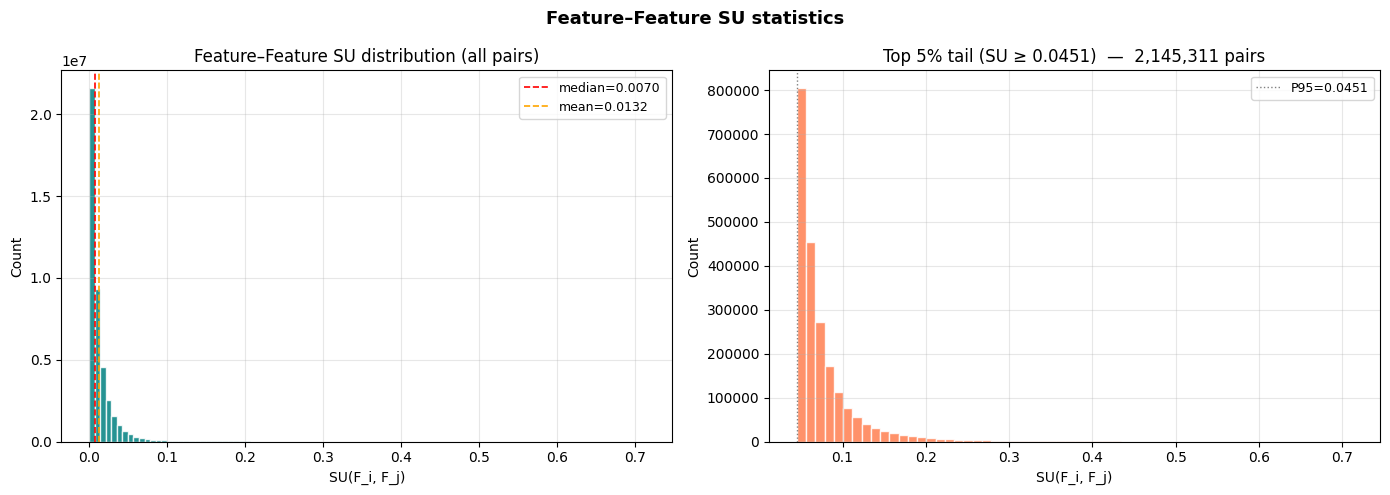

In [6]:
# Extract upper triangle of feature–feature SU (excluding diagonal)
su_ff = su_df.loc[feature_names, feature_names].values
iu = np.triu_indices(len(feature_names), k=1)
ff_values = su_ff[iu]

print(f'Feature–feature pairs: {len(ff_values):,}')
print(f'  min    = {ff_values.min():.6f}')
print(f'  max    = {ff_values.max():.6f}')
print(f'  mean   = {ff_values.mean():.6f}')
print(f'  median = {np.median(ff_values):.6f}')
print(f'  std    = {ff_values.std():.6f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(ff_values, bins=100, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(np.median(ff_values), color='red', ls='--', lw=1.2, label=f'median={np.median(ff_values):.4f}')
ax.axvline(ff_values.mean(), color='orange', ls='--', lw=1.2, label=f'mean={ff_values.mean():.4f}')
ax.set_xlabel('SU(F_i, F_j)')
ax.set_ylabel('Count')
ax.set_title('Feature–Feature SU distribution (all pairs)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Zoom into the tail (top 5%)
ax = axes[1]
p95 = np.percentile(ff_values, 95)
tail = ff_values[ff_values >= p95]
ax.hist(tail, bins=60, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(p95, color='grey', ls=':', lw=1, label=f'P95={p95:.4f}')
ax.set_xlabel('SU(F_i, F_j)')
ax.set_ylabel('Count')
ax.set_title(f'Top 5% tail (SU \u2265 {p95:.4f})  —  {len(tail):,} pairs')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle('Feature–Feature SU statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### MB pruning margin analysis

For each feature pair where $SU(F_i, C) \ge SU(F_j, C)$ (the first
MB condition), compute the margin $SU(F_i, F_j) - SU(F_j, C)$.
Only positive margins trigger pruning under `mb_threshold=0`.
The distribution of these margins shows what threshold values would
meaningfully reduce pruning.

Positive pruning margins (target=is_lumA): 17,059,264
  min    = 0.000000
  max    = 0.680706
  mean   = 0.012548
  median = 0.005601
  P25    = 0.001818
  P50    = 0.005601
  P75    = 0.014621
  P90    = 0.030400
  P95    = 0.045884
  P99    = 0.104367


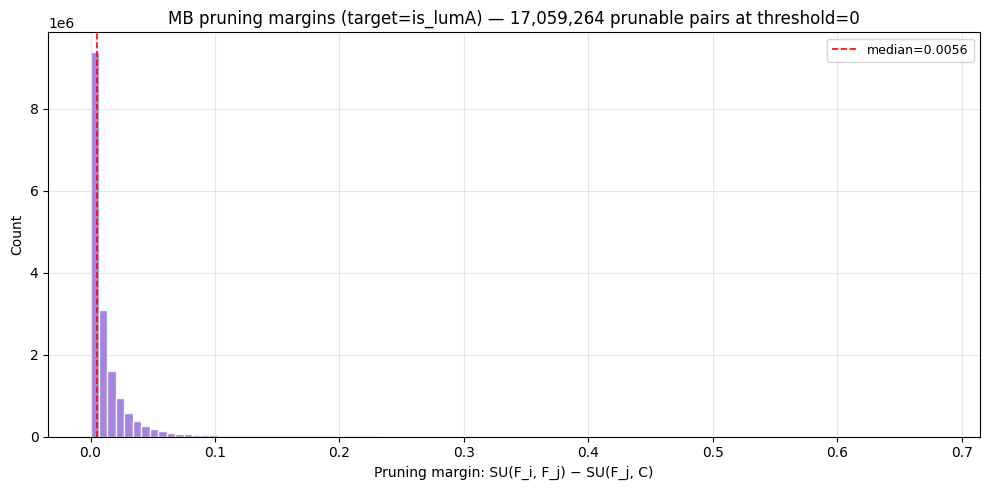

In [10]:
# Compute MB pruning margins for is_lumA target
tgt = 'is_lumA'
if tgt in su_df.columns:
    su_fC = su_df.loc[feature_names, tgt].values  # SU(f, C) for each feature
    su_ff_mat = su_df.loc[feature_names, feature_names].values

    # For each pair (i, j) where SU(F_i, C) >= SU(F_j, C):
    # margin = SU(F_i, F_j) - SU(F_j, C)
    margins = []
    n = len(feature_names)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if su_fC[i] >= su_fC[j]:
                margin = su_ff_mat[i, j] - su_fC[j]
                if margin > 0:  # only positive margins (would be pruned at threshold=0)
                    margins.append(margin)

    margins = np.array(margins)
    print(f'Positive pruning margins (target={tgt}): {len(margins):,}')
    if len(margins) > 0:
        print(f'  min    = {margins.min():.6f}')
        print(f'  max    = {margins.max():.6f}')
        print(f'  mean   = {margins.mean():.6f}')
        print(f'  median = {np.median(margins):.6f}')
        for pct in [25, 50, 75, 90, 95, 99]:
            print(f'  P{pct:02d}    = {np.percentile(margins, pct):.6f}')

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.hist(margins, bins=100, color='mediumpurple', edgecolor='white', alpha=0.85)
        ax.axvline(np.median(margins), color='red', ls='--', lw=1.2, label=f'median={np.median(margins):.4f}')
        ax.set_xlabel('Pruning margin: SU(F_i, F_j) − SU(F_j, C)')
        ax.set_ylabel('Count')
        ax.set_title(f'MB pruning margins (target={tgt}) — {len(margins):,} prunable pairs at threshold=0')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print(f'{tgt} not found in SU matrix.')

---

## Task A — Classification (is_lumA), IWSS-MB, Mode A

### A.1 — Run IWSS-MB selector

In [11]:
ws_clf = WrapperSelector(
    X_train=X_train,
    y_train=y_lumA,
    X_val=X_val,
    y_val=y_lumA_val,
    use_su_ranking=True,          # IWSS: rank by SU(f, C) descending
    use_mb_pruning=True,          # MB: prune redundant candidates after each selection
    mb_threshold=MB_THRESHOLD,    # MB pruning margin (0.0 = original paper)
    cv_folds=CV_FOLDS,
    cv_min_folds=CV_MIN_FOLDS,
    patience=PATIENCE,
    su_filepath=SU_PATH,          # Mode A: shared SU matrix (feature-pairs computed once)
    random_seed=RANDOM_SEED,
)

result_clf: WrapperSelectionResult = ws_clf.run(
    n_features_to_select=N_FEATURES,
    test_eval_every_k=TEST_EVAL_EVERY,
)

print()
print(result_clf)

2026-04-12 13:34:32,648 [INFO] ScoreMatrix: Loaded score matrix from ../data/su_matrix.csv (9266×9266, 85840225 valid entries)
2026-04-12 13:34:33,659 [INFO] WrapperSelector: Filter init done in 34.088s | SU target col filled | Mode A | top candidate: MYBL2 (SU=0.2676)
2026-04-12 13:34:33,661 [INFO] WrapperSelector: WrapperSelector initialised | task=classification | use_su_ranking=True | use_mb_pruning=True | mb_threshold=0.0050 | cv_folds=5 | cv_min_folds=3 | patience=None | n_candidates=9264
2026-04-12 13:34:33,704 [INFO] WrapperSelector: Step 1 (IWSS): selected 'MYBL2' mean_cv=0.8087 n_improved=5
2026-04-12 13:34:33,714 [INFO] WrapperSelector:   MB pruned 2839 candidates
2026-04-12 13:34:33,740 [INFO] WrapperSelector: Step 2 (IWSS): selected 'MAPT' mean_cv=0.8357 n_improved=5
2026-04-12 13:34:33,747 [INFO] WrapperSelector:   MB pruned 2510 candidates
2026-04-12 13:34:33,768 [DEBUG] WrapperSelector:   Candidate 'CACNA1D' rejected (mean=0.8352 n_imp=2 streak=1)
2026-04-12 13:34:33,78

### A.2 — Timing breakdown

In [12]:
print('Timing breakdown:')
print(f'  Total selection time   : {result_clf.selection_time_seconds:.3f}s')
print(f'    └─ Filter init time  : {result_clf.filter_time_seconds:.3f}s')
print(f'    └─ Evaluator CV time : {result_clf.classifier_time_seconds:.3f}s')
print(f'  Test eval time (val)   : {result_clf.test_evaluation_time_seconds:.3f}s')
print(f'\nWrapper CV evaluations   : {result_clf.n_wrapper_evaluations}')
print(f'Candidates pruned (MB)   : {result_clf.n_candidates_pruned}')
print(f'Evaluations skipped (MB) : {result_clf.n_evaluations_skipped}')
print(f'Stopping reason          : {result_clf.stopping_reason}')

Timing breakdown:
  Total selection time   : 36.740s
    └─ Filter init time  : 34.088s
    └─ Evaluator CV time : 2.373s
  Test eval time (val)   : 0.112s

Wrapper CV evaluations   : 79
Candidates pruned (MB)   : 8415
Evaluations skipped (MB) : 8415
Stopping reason          : max_features_reached


### A.3 — Selected features

In [13]:
print(f'Classification — {len(result_clf.selected_features)} features selected (in order):')
for i, f in enumerate(result_clf.selected_features, 1):
    print(f'  {i:2d}. {f}')

# Inspect first history entry — includes 'step' key
if result_clf.performance_history:
    print('\nFirst performance history entry:')
    display(pd.Series({
        k: v for k, v in result_clf.performance_history[0].items()
        if k not in ('macro avg', 'weighted avg')
    }))

Classification — 20 features selected (in order):
   1. MYBL2
   2. MAPT
   3. SCN2B
   4. MATN3
   5. ALAD
   6. JMJD6
   7. DOCK1
   8. RUNX1
   9. GLT8D1
  10. TDO2
  11. SPTAN1
  12. ATP7B
  13. CCNG2
  14. VIPR2
  15. FANCE
  16. ABCD1
  17. GP2
  18. POLR2F
  19. RUFY1
  20. AMD1

First performance history entry:


0           {'precision': 0.815068493150685, 'recall': 0.7...
1           {'precision': 0.8125, 'recall': 0.828025477707...
accuracy                                             0.813725
step                                                        2
dtype: object

### A.4 — LR random baseline

Running experiments: 100%|██████████| 10/10 [00:21<00:00,  2.11s/it]


Summary Statistics (Mean +/- Std Dev):



,features_num,variable,mean,std
0,2,f1-score,0.604881,0.034663
1,2,precision,0.605392,0.034584
2,2,recall,0.605198,0.034504
3,8,f1-score,0.701096,0.044530
4,8,precision,0.701944,0.044669
5,8,recall,0.701233,0.044637
6,10,f1-score,0.715280,0.048491
7,10,precision,0.716583,0.048612
8,10,recall,0.715332,0.048342
9,14,f1-score,0.739194,0.041332


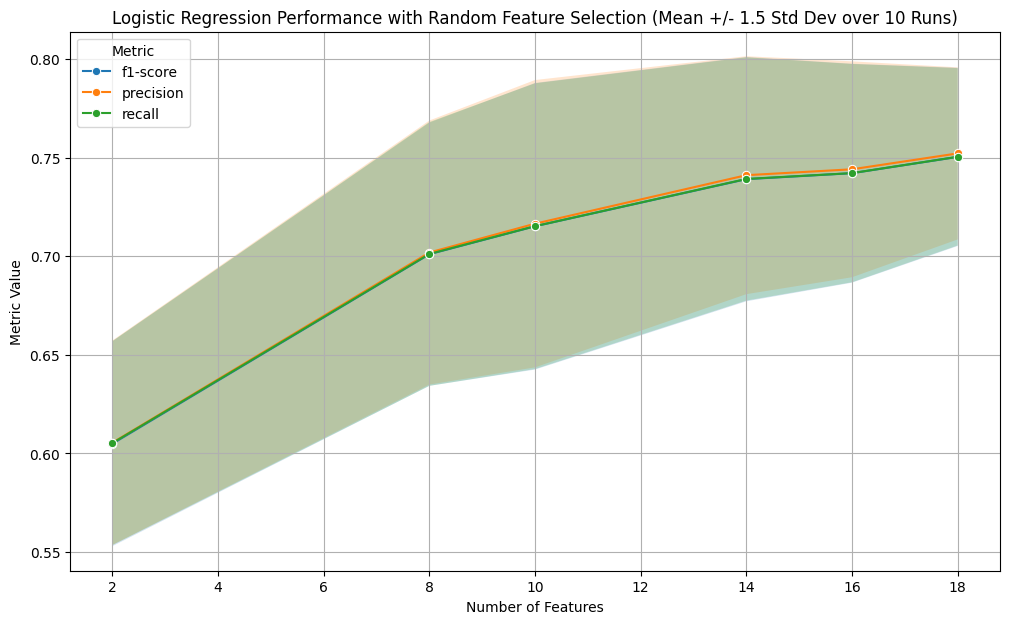

In [14]:
# N_values = number of features selected at each evaluated checkpoint (NOT a loop index)
checkpoints_clf = [entry['step'] for entry in result_clf.performance_history]

baseline_summary_clf = clf_baseline_plot(
    gene_expression_df=gene_expression_df,
    train_labels_df=train_labels_df,
    val_labels_df=val_labels_df,
    N_values=checkpoints_clf,
    random_seed=RANDOM_SEED,
    num_runs=N_RUNS,
    return_summary=True,
)

### A.5 — Comparison plot


Summary Statistics — Random Baseline (Mean ± Std):


,features_num,acc_mean,acc_std,f1_mean,f1_std
0,2,0.605229,0.034715,0.604881,0.034663
1,8,0.701634,0.044411,0.701096,0.044530
2,10,0.716013,0.048434,0.715280,0.048491
3,14,0.740196,0.040708,0.739194,0.041332
4,16,0.743137,0.036657,0.742214,0.037037
5,18,0.751307,0.029651,0.750495,0.030141


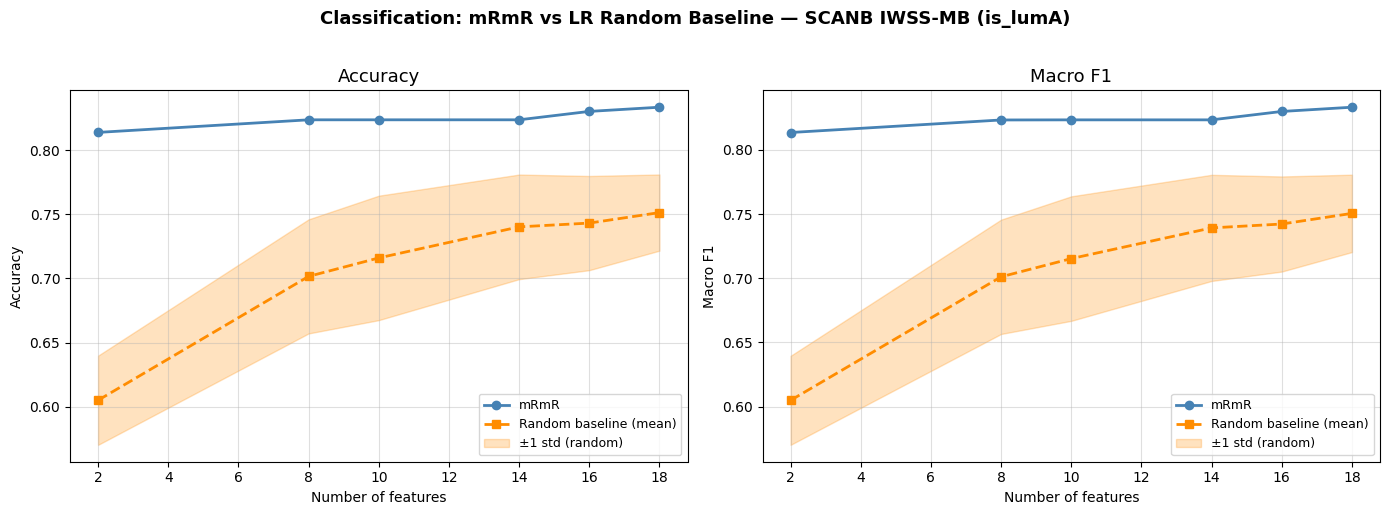

In [15]:
result_clf.plot_vs_random_baseline(
    baseline_summary=baseline_summary_clf,
    title_suffix=' — SCANB IWSS-MB (is_lumA)',
)

---

## Task B — Regression (Lympho), IWSS-MB, Mode A

### B.1 — Run IWSS-MB selector

In [27]:
ws_reg = WrapperSelector(
    X_train=X_train,
    y_train=y_lympho,
    X_val=X_val,
    y_val=y_lympho_val,
    use_su_ranking=True,
    use_mb_pruning=True,
    mb_threshold=MB_THRESHOLD,
    cv_folds=CV_FOLDS,
    cv_min_folds=CV_MIN_FOLDS,
    patience=PATIENCE,
    su_filepath=SU_PATH,          # same shared SU matrix — Lympho column already present
    random_seed=RANDOM_SEED,
)

result_reg: WrapperSelectionResult = ws_reg.run(
    n_features_to_select=N_FEATURES,
    test_eval_every_k=TEST_EVAL_EVERY,
)

print()
print(result_reg)

2026-04-12 13:39:47,499 [INFO] ScoreMatrix: Loaded score matrix from ../data/su_matrix.csv (9266×9266, 85840225 valid entries)
2026-04-12 13:39:48,518 [INFO] WrapperSelector: Filter init done in 35.840s | SU target col filled | Mode A | top candidate: CD247 (SU=0.5866)
2026-04-12 13:39:48,519 [INFO] WrapperSelector: WrapperSelector initialised | task=regression | use_su_ranking=True | use_mb_pruning=True | mb_threshold=0.0050 | cv_folds=5 | cv_min_folds=3 | patience=None | n_candidates=9264
2026-04-12 13:39:48,543 [INFO] WrapperSelector: Step 1 (IWSS): selected 'CD247' mean_cv=0.9170 n_improved=5
2026-04-12 13:39:48,550 [INFO] WrapperSelector:   MB pruned 189 candidates
2026-04-12 13:39:48,563 [INFO] WrapperSelector: Step 2 (IWSS): selected 'IL2RG' mean_cv=0.9509 n_improved=5
2026-04-12 13:39:48,570 [INFO] WrapperSelector:   MB pruned 1290 candidates
2026-04-12 13:39:48,581 [INFO] WrapperSelector: Step 3 (IWSS): selected 'ACAP1' mean_cv=0.9661 n_improved=5
2026-04-12 13:39:48,587 [INFO

### B.2 — Selected features

In [28]:
print(f'Regression — {len(result_reg.selected_features)} features selected (in order):')
for i, f in enumerate(result_reg.selected_features, 1):
    print(f'  {i:2d}. {f}')

Regression — 20 features selected (in order):
   1. CD247
   2. IL2RG
   3. ACAP1
   4. MAP4K1
   5. CD48
   6. ITK
   7. LY9
   8. CD3G
   9. SLAMF1
  10. UBASH3A
  11. SH2D1A
  12. CD27
  13. IKZF3
  14. PYHIN1
  15. NKG7
  16. PRKCB
  17. PRKCQ
  18. TRAF3IP3
  19. CCR5
  20. JAK3


### B.3 — LinReg random baseline

Running LinReg experiments: 100%|██████████| 10/10 [00:00<00:00, 44.96it/s]


Summary Statistics — Linear Regression Random Baseline (Mean ± Std):



,features_num,r2_mean,r2_std,mse_mean,mse_std,mae_mean,mae_std
0,8,0.337230,0.240140,0.604453,0.219010,0.596585,0.132432
1,12,0.381314,0.223988,0.564248,0.204279,0.572678,0.124453
2,18,0.487832,0.206206,0.467102,0.188062,0.519213,0.124556


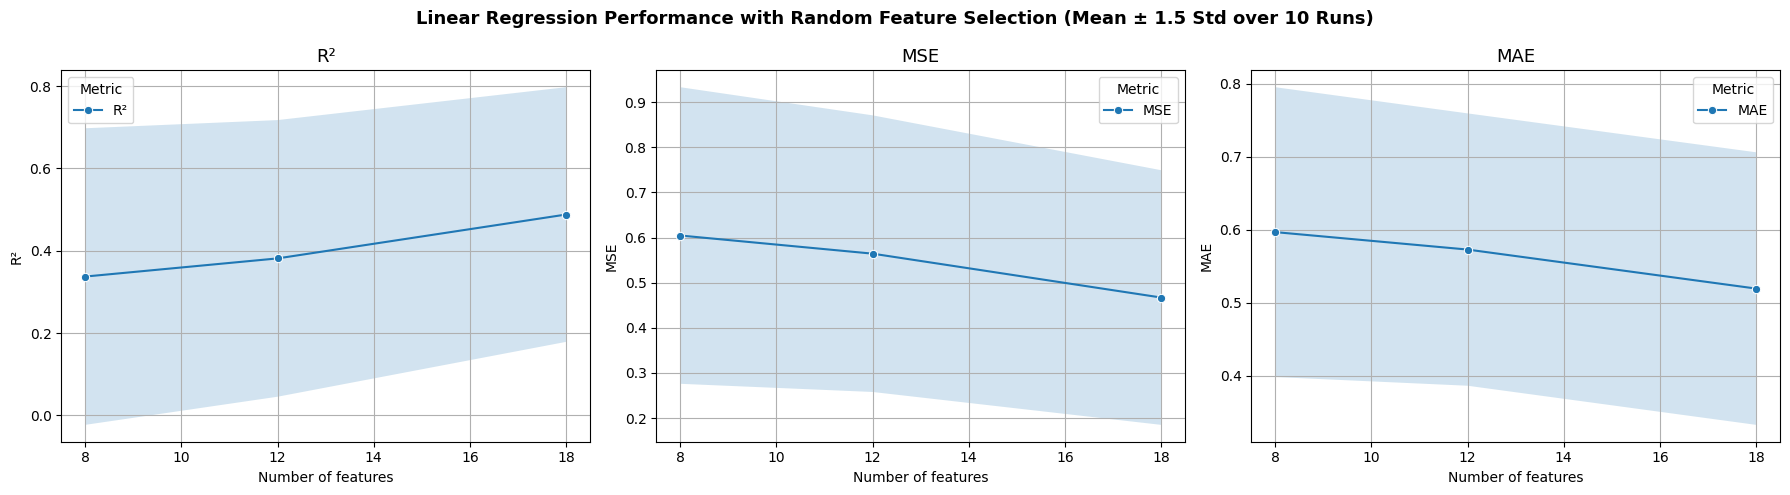

In [29]:
# N_values = number of features selected at each evaluated checkpoint
checkpoints_reg = [entry['step'] for entry in result_reg.performance_history]

baseline_summary_reg = reg_baseline_plot(
    X_train=X_train,
    y_train=y_lympho,
    X_val=X_val,
    y_val=y_lympho_val,
    N_values=checkpoints_reg,
    random_seed=RANDOM_SEED,
    num_runs=N_RUNS,
    return_summary=True,
)

### B.4 — Comparison plot


Summary Statistics — LinReg Random Baseline (Mean ± Std):


,features_num,r2_mean,r2_std,mse_mean,mse_std,mae_mean,mae_std
0,8,0.337230,0.240140,0.604453,0.219010,0.596585,0.132432
1,12,0.381314,0.223988,0.564248,0.204279,0.572678,0.124453
2,18,0.487832,0.206206,0.467102,0.188062,0.519213,0.124556


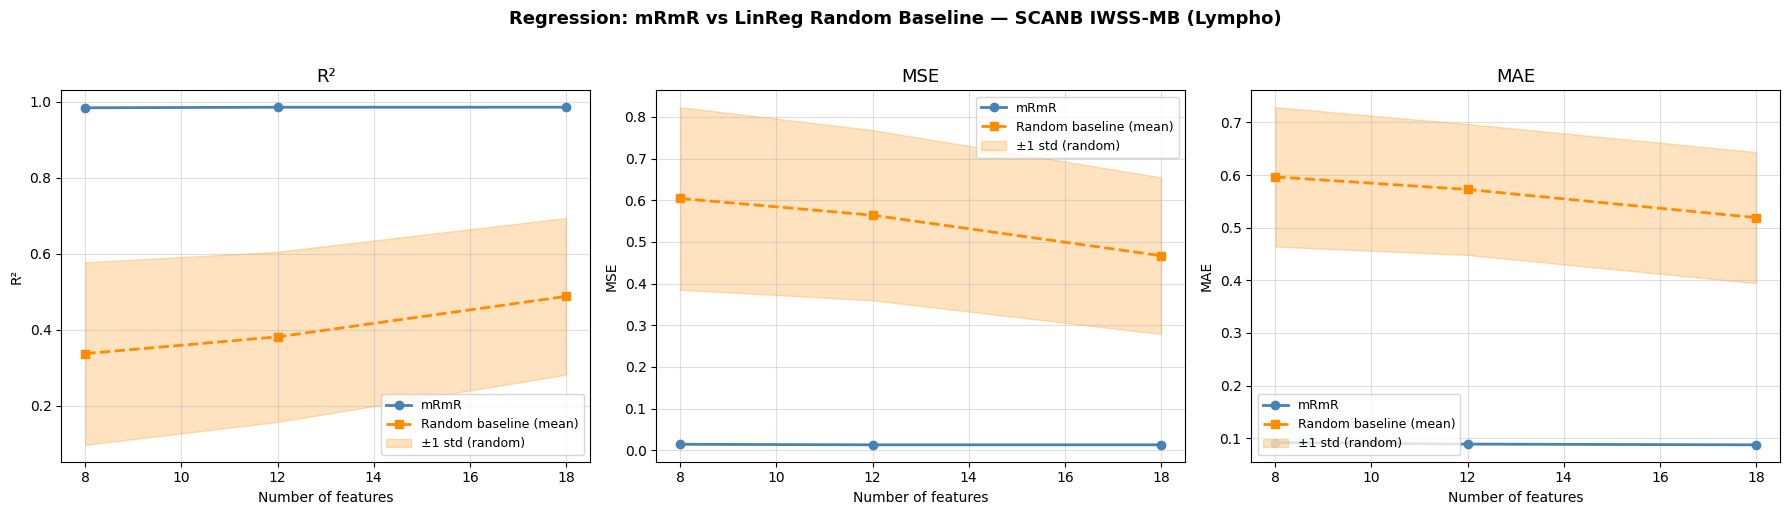

In [30]:
result_reg.plot_vs_random_baseline(
    baseline_summary=baseline_summary_reg,
    title_suffix=' — SCANB IWSS-MB (Lympho)',
)

---

## Task C — All four algorithm variants compared (is_lumA, Mode B)

Run all four `WrapperSelector` variants without a precomputed SU file (Mode B —
lazy incremental column-fill) and compare their performance histories.

| Variant | `use_su_ranking` | `use_mb_pruning` |
|---------|-----------------|------------------|
| SFS     | False           | False            |
| SFS-MB  | False           | True             |
| IWSS    | True            | False            |
| IWSS-MB | True            | True             |

### C.1 — Run all four variants

In [33]:
N_COMPARE = 30   # fewer features to keep SFS runtime manageable

variants = [
    #('SFS',     False, False),
    #('SFS-MB',  False, True),
    ('IWSS',    True,  False),
    ('IWSS-MB', True,  True),
]

results_C = {}   # label → WrapperSelectionResult

for label, use_su, use_mb in variants:
    print(f'\n=== {label} (use_su_ranking={use_su}, use_mb_pruning={use_mb}) ===')
    ws = WrapperSelector(
        X_train=X_train,
        y_train=y_lumA,
        X_val=X_val,
        y_val=y_lumA_val,
        use_su_ranking=use_su,
        use_mb_pruning=use_mb,
        mb_threshold=MB_THRESHOLD,
        cv_folds=CV_FOLDS,
        cv_min_folds=CV_MIN_FOLDS,
        patience=PATIENCE,
        # su_filepath=None → Mode B lazy fill
        random_seed=RANDOM_SEED,
    )
    result = ws.run(
        n_features_to_select=N_COMPARE,
        test_eval_every_k=1,
    )
    results_C[label] = result
    print(f'  Selected: {result.selected_features}')
    print(f'  Stopping: {result.stopping_reason}')
    print(f'  CV evals: {result.n_wrapper_evaluations}  '
          f'Pruned: {result.n_candidates_pruned}  '
          f'Time: {result.selection_time_seconds:.3f}s')


=== IWSS (use_su_ranking=True, use_mb_pruning=False) ===
2026-04-12 13:42:09,001 [INFO] ScoreCalculator: init_target complete: method=su, N=9264 features, target=is_lumA
2026-04-12 13:42:09,004 [INFO] WrapperSelector: Filter init done in 1.201s | SU target col filled | Mode B | top candidate: MYBL2 (SU=0.2676)
2026-04-12 13:42:09,005 [INFO] WrapperSelector: WrapperSelector initialised | task=classification | use_su_ranking=True | use_mb_pruning=False | mb_threshold=0.0100 | cv_folds=5 | cv_min_folds=3 | patience=None | n_candidates=9264
2026-04-12 13:42:09,030 [INFO] WrapperSelector: Step 1 (IWSS): selected 'MYBL2' mean_cv=0.8087 n_improved=5
2026-04-12 13:42:09,044 [INFO] WrapperSelector:   Test eval step 1 — accuracy: 0.7778
2026-04-12 13:42:09,065 [INFO] WrapperSelector: Step 2 (IWSS): selected 'CDC45' mean_cv=0.8208 n_improved=4
2026-04-12 13:42:09,077 [INFO] WrapperSelector:   Test eval step 2 — accuracy: 0.7876
2026-04-12 13:42:09,102 [INFO] WrapperSelector: Step 3 (IWSS): selec

### C.2 — Timing and efficiency comparison table

In [34]:
timing_rows = []
for label, res in results_C.items():
    timing_rows.append({
        'variant': label,
        'features_selected': len(res.selected_features),
        'stopping_reason': res.stopping_reason,
        'total_time_s': round(res.selection_time_seconds, 4),
        'filter_time_s': round(res.filter_time_seconds, 4),
        'clf_time_s': round(res.classifier_time_seconds, 4),
        'cv_evaluations': res.n_wrapper_evaluations,
        'pruned': res.n_candidates_pruned,
        'skipped_evals': res.n_evaluations_skipped,
    })

timing_df = pd.DataFrame(timing_rows).set_index('variant')
print('Algorithm variant comparison:')
display(timing_df)

Algorithm variant comparison:


,features_selected,stopping_reason,total_time_s,filter_time_s,clf_time_s,cv_evaluations,pruned,skipped_evals
variant,,,,,,,,
IWSS,30,max_features_reached,39.9107,1.2015,37.1626,925,0,0
IWSS-MB,30,max_features_reached,9.1004,1.2149,3.8115,125,7912,7912


### C.3 — Evaluator-call count and timing bar charts

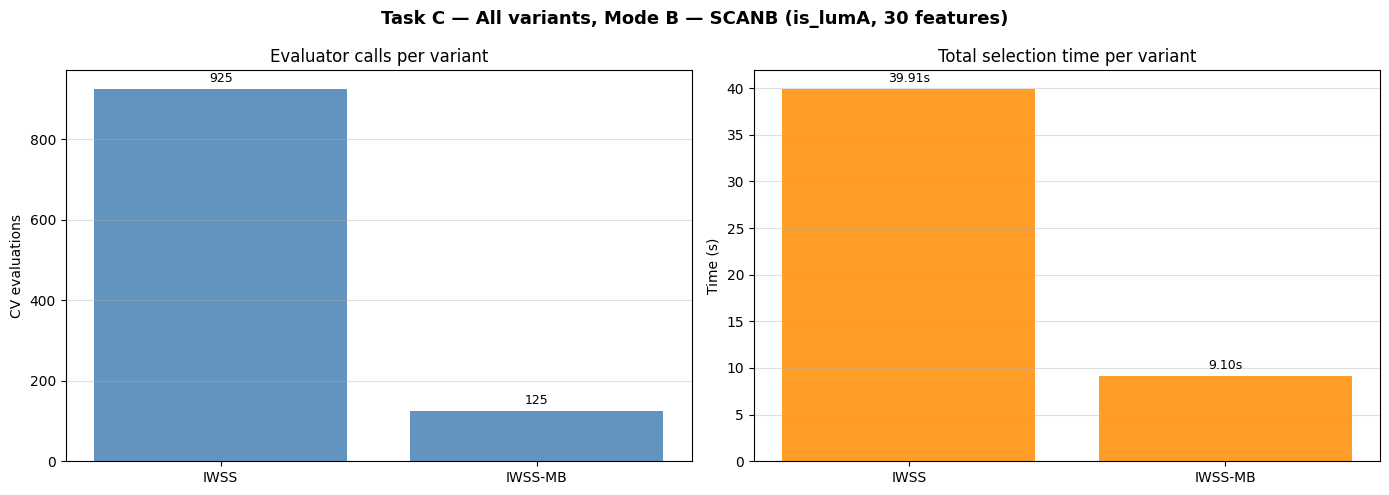

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

variants_order = list(results_C.keys())
eval_counts  = [results_C[v].n_wrapper_evaluations for v in variants_order]
total_times  = [results_C[v].selection_time_seconds for v in variants_order]

ax = axes[0]
bars = ax.bar(variants_order, eval_counts, color='steelblue', alpha=0.85)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Evaluator calls per variant', fontsize=12)
ax.set_ylabel('CV evaluations')
ax.grid(True, axis='y', alpha=0.4)

ax = axes[1]
bars = ax.bar(variants_order, total_times, color='darkorange', alpha=0.85)
ax.bar_label(bars, fmt='{:.2f}s', padding=3, fontsize=9)
ax.set_title('Total selection time per variant', fontsize=12)
ax.set_ylabel('Time (s)')
ax.grid(True, axis='y', alpha=0.4)

fig.suptitle(
    f'Task C — All variants, Mode B — SCANB (is_lumA, {N_COMPARE} features)',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
plt.show()

### C.4 — Performance comparison plot

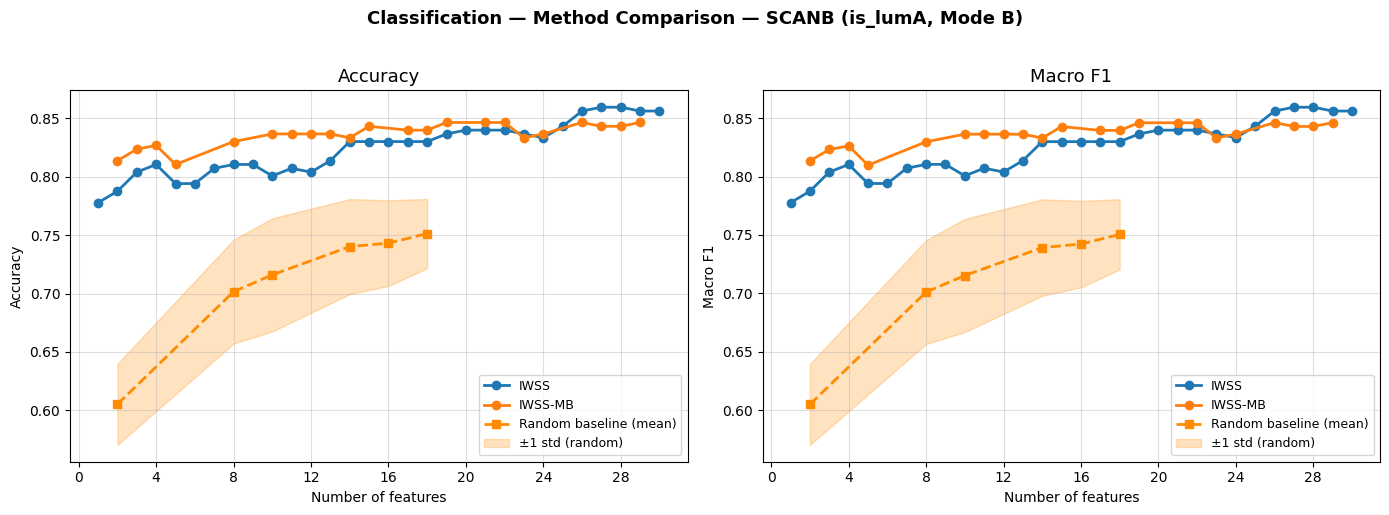

In [36]:
# Only compare results that have performance history entries
valid_results = {k: v for k, v in results_C.items() if v.performance_history}

if valid_results:
    SelectionResult.compare_results(
        results=list(valid_results.values()),
        labels=list(valid_results.keys()),
        baseline_summary=baseline_summary_clf,
        title_suffix=' — SCANB (is_lumA, Mode B)',
    )
else:
    print('No results with performance history to compare.')

### C.5 — Feature diff: IWSS vs IWSS-MB

In [37]:
if 'IWSS' in results_C and 'IWSS-MB' in results_C:
    results_C['IWSS'].compare_with(
        results_C['IWSS-MB'],
        self_label='IWSS',
        other_label='IWSS-MB',
    )
else:
    print('IWSS or IWSS-MB result not available.')


Comparing IWSS (N=30) vs IWSS-MB (N=30)
──────┼───────────┼───────────
rank │ IWSS      │ IWSS-MB  
──────┼───────────┼───────────
   1 │ MYBL2     │ MYBL2    
   2 │ CDC45     │ MAPT     
   3 │ BIRC5     │ SCN2B    
   4 │ PTTG1     │ MATN3    
   5 │ CENPA     │ ALAD     
   6 │ AURKA     │ RAI2     
   7 │ SHCBP1    │ JMJD6    
   8 │ CEP55     │ DOCK1    
   9 │ ORC6      │ UQCRH    
  10 │ MAD2L1    │ IGFALS   
  11 │ CCNB1     │ TIGD6    
  12 │ DDX39A    │ KLHL9    
  13 │ SPC25     │ ARHGEF38 
  14 │ MAPT      │ BTD      
  15 │ DIAPH3    │ ARHGAP32 
  16 │ STIL      │ SLC25A13 
  17 │ UBE2S     │ TBC1D19  
  18 │ MCM2      │ TECPR2   
  19 │ TUBA1C    │ VIPR2    
  20 │ ARHGAP11A │ GARS     
  21 │ FANCI     │ DLX2     
  22 │ DYNC2H1   │ TMEM8B   
  23 │ SCN2B     │ SLBP     
  24 │ SNRPA1    │ AIM2     
  25 │ CA12      │ CAMKV    
  26 │ RANBP1    │ TALDO1   
  27 │ TIMELESS  │ COQ9     
  28 │ STC2      │ TCEA2    
  29 │ OSBPL1A   │ PLAT     
  30 │ REEP4     │ LAMA3   

### C.6 — Summary report: all four variants

In [38]:
summary_df = SelectionResult.summary_report(
    results=list(results_C.values()),
    labels=list(results_C.keys()),
)


Feature summary across 2 results (57 unique features):
Labels: IWSS, IWSS-MB



,feature,count,pct,mean_rank,min_rank,max_rank,selected_by
0,MYBL2,2,100.0,1.0,1,1,"IWSS, IWSS-MB"
1,MAPT,2,100.0,8.0,2,14,"IWSS-MB, IWSS"
2,SCN2B,2,100.0,13.0,3,23,"IWSS-MB, IWSS"
3,CDC45,1,50.0,2.0,2,2,IWSS
4,BIRC5,1,50.0,3.0,3,3,IWSS
5,PTTG1,1,50.0,4.0,4,4,IWSS
6,MATN3,1,50.0,4.0,4,4,IWSS-MB
7,CENPA,1,50.0,5.0,5,5,IWSS
8,ALAD,1,50.0,5.0,5,5,IWSS-MB
9,AURKA,1,50.0,6.0,6,6,IWSS


---

## Summary — Timing across all tasks

In [39]:
print('=== Task A — Classification IWSS-MB (is_lumA, Mode A) ===')
print(f'  Features selected    : {len(result_clf.selected_features)}')
print(f'  Total time           : {result_clf.selection_time_seconds:.3f}s')
print(f'    └─ Filter init     : {result_clf.filter_time_seconds:.3f}s')
print(f'    └─ Evaluator CV    : {result_clf.classifier_time_seconds:.3f}s')
print(f'  Test eval time (val) : {result_clf.test_evaluation_time_seconds:.3f}s')
print(f'  CV evaluations       : {result_clf.n_wrapper_evaluations}')
print(f'  Candidates pruned    : {result_clf.n_candidates_pruned}')
print(f'  Stopping reason      : {result_clf.stopping_reason}')

print()
print('=== Task B — Regression IWSS-MB (Lympho, Mode A) ===')
print(f'  Features selected    : {len(result_reg.selected_features)}')
print(f'  Total time           : {result_reg.selection_time_seconds:.3f}s')
print(f'    └─ Filter init     : {result_reg.filter_time_seconds:.3f}s')
print(f'    └─ Evaluator CV    : {result_reg.classifier_time_seconds:.3f}s')
print(f'  Test eval time (val) : {result_reg.test_evaluation_time_seconds:.3f}s')
print(f'  CV evaluations       : {result_reg.n_wrapper_evaluations}')
print(f'  Candidates pruned    : {result_reg.n_candidates_pruned}')
print(f'  Stopping reason      : {result_reg.stopping_reason}')

print()
print('=== Task C — All four variants (is_lumA, Mode B) ===')
display(timing_df)

=== Task A — Classification IWSS-MB (is_lumA, Mode A) ===
  Features selected    : 20
  Total time           : 36.740s
    └─ Filter init     : 34.088s
    └─ Evaluator CV    : 2.373s
  Test eval time (val) : 0.112s
  CV evaluations       : 79
  Candidates pruned    : 8415
  Stopping reason      : max_features_reached

=== Task B — Regression IWSS-MB (Lympho, Mode A) ===
  Features selected    : 20
  Total time           : 36.304s
    └─ Filter init     : 35.840s
    └─ Evaluator CV    : 0.296s
  Test eval time (val) : 0.013s
  CV evaluations       : 26
  Candidates pruned    : 4670
  Stopping reason      : max_features_reached

=== Task C — All four variants (is_lumA, Mode B) ===


,features_selected,stopping_reason,total_time_s,filter_time_s,clf_time_s,cv_evaluations,pruned,skipped_evals
variant,,,,,,,,
IWSS,30,max_features_reached,39.9107,1.2015,37.1626,925,0,0
IWSS-MB,30,max_features_reached,9.1004,1.2149,3.8115,125,7912,7912
